In [ ]:
!pip uninstall -y sympy
!pip install sympy==1.12
!pip install -U torch torchvision --quiet

Found existing installation: sympy 1.12
Uninstalling sympy-1.12:
  Successfully uninstalled sympy-1.12
  Using cached sympy-1.12-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.12-py3-none-any.whl (5.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.9.0+cpu requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.

REPRISE

In [ ]:
print("=== CELLULE : Import du dataset principal (Celltool) ===")
print("Pourquoi ? Charger les images actine et noyaux pour toutes les conditions.")
print("------------------------------------------------------------\n")

import zipfile
import os
from pathlib import Path

# Chemin du zip (dans Colab)
ZIP_PATH = "/content/Celltool.zip"

# Dossier d'extraction
EXTRACT_DIR = "/content/dataset"

# Création du dossier
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extraction
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("✅ Extraction terminée.")

# Détection automatique du dossier contenant les conditions
root = Path(EXTRACT_DIR)

# Cherche un dossier qui contient Ctrl/TGF/TNF/TNFTGF
DATA_DIR = None
for p in root.rglob("*"):
    if p.is_dir():
        sub = {d.name for d in p.iterdir() if d.is_dir()}
        if {"Ctrl", "TGF", "TNF", "TNFTGF"}.issubset(sub):
            DATA_DIR = str(p)
            break

if DATA_DIR is None:
    raise RuntimeError("❌ Impossible de trouver le dossier contenant les conditions.")

print("📂 DATA_DIR détecté :", DATA_DIR)

# Vérification des conditions
conds = [d.name for d in Path(DATA_DIR).iterdir() if d.is_dir()]
print("Conditions trouvées :", sorted(conds))


=== CELLULE : Import du dataset principal (Celltool) ===
Pourquoi ? Charger les images actine et noyaux pour toutes les conditions.
------------------------------------------------------------

✅ Extraction terminée.
📂 DATA_DIR détecté : /content/dataset/Celltool
Conditions trouvées : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']


In [ ]:
import os
from pathlib import Path

print("=== CELLULE 1 : Définir DATA_DIR ===")
print("Pourquoi ? Le code doit savoir où sont tes dossiers Ctrl/TGF/TNF/TNFTGF.\n")

# ✅ Ton dataset est en double : Celltool/ et Celltool/Celltool/
# On choisit la racine propre qui contient directement Ctrl, TGF, TNF, TNFTGF
DATA_DIR = "/content/dataset/Celltool"

p = Path(DATA_DIR)
print("DATA_DIR =", DATA_DIR)
print("DATA_DIR existe ?", p.exists())

if not p.exists():
    raise RuntimeError("❌ DATA_DIR n'existe pas. Vérifie ton extraction du zip.")

conds = sorted([d.name for d in p.iterdir() if d.is_dir()])
print("Sous-dossiers trouvés (conditions) :", conds)

print("\n✅ Ce que tu dois voir : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']")


=== CELLULE 1 : Définir DATA_DIR ===
Pourquoi ? Le code doit savoir où sont tes dossiers Ctrl/TGF/TNF/TNFTGF.

DATA_DIR = /content/dataset/Celltool
DATA_DIR existe ? True
Sous-dossiers trouvés (conditions) : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']

✅ Ce que tu dois voir : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']


In [ ]:
print("=== CELLULE 2 : Imports + seed ===")
print("Pourquoi ? Charger les librairies + rendre les résultats reproductibles.\n")

import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}
print("✅ Imports OK | Seed=42 OK")
print("Torch version :", torch.__version__)
print("GPU dispo ?   :", torch.cuda.is_available())


=== CELLULE 2 : Imports + seed ===
Pourquoi ? Charger les librairies + rendre les résultats reproductibles.

✅ Imports OK | Seed=42 OK
Torch version : 2.9.0+cu128
GPU dispo ?   : True


In [ ]:
print("=== CELLULE 3 : Transformations d’images ===")
print("Pourquoi ? Mettre toutes les images au même format pour le réseau.")
print("Bio : toutes les cellules sont observées à la même échelle et intensité.")
print("------------------------------------------------------------\n")

from torchvision import transforms

IMG_SIZE = 224

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # convertit l'image en tenseur (0–1)
])

print("✅ Transformations créées.")
print(" - Taille finale des images :", IMG_SIZE, "x", IMG_SIZE)
print(" - Normalisation : valeurs entre 0 et 1")


=== CELLULE 3 : Transformations d’images ===
Pourquoi ? Mettre toutes les images au même format pour le réseau.
Bio : toutes les cellules sont observées à la même échelle et intensité.
------------------------------------------------------------

✅ Transformations créées.
 - Taille finale des images : 224 x 224
 - Normalisation : valeurs entre 0 et 1


In [ ]:
from pathlib import Path
from PIL import Image
import numpy as np

print("=== CELLULE 4 : Dataset pairé actine/noyau ===")
print("Pourquoi ? Garantir que Actine et Noyaux correspondent à LA MÊME cellule.")
print("Bio : une cellule = 2 mesures (actine + noyau) sur le même identifiant (ex: Ctrl0.png).")
print("------------------------------------------------------------\n")

# Extensions d'images acceptées
IMG_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".webp"}

class PairedActinNucleusDataset(Dataset):
    """
    Dataset qui renvoie :
    actine_tensor, noyau_tensor, label_condition, sample_id
    """

    def __init__(self, root_dir, transform_actin=None, transform_nuc=None, verbose=True):
        self.root = Path(root_dir)
        self.tA = transform_actin
        self.tN = transform_nuc
        self.verbose = verbose

        if not self.root.exists():
            raise RuntimeError(f"❌ root_dir n'existe pas: {root_dir}")

        # 1) trouver les conditions (Ctrl, TGF, TNF, TNFTGF)
        self.conditions = sorted([
            d.name for d in self.root.iterdir()
            if d.is_dir() and not d.name.startswith(".")
        ])
        if not self.conditions:
            raise RuntimeError("❌ Aucune condition détectée.")

        self.cond_to_idx = {c: i for i, c in enumerate(self.conditions)}
        self.samples = []  # (cond, filename, act_path, nuc_path)

        print("✅ Conditions détectées :", self.conditions)
        print("\nÉtape A — On construit les paires (intersection des noms de fichiers)")
        print("Rappel : on garde seulement les cellules qui ont actine ET noyau.\n")

        # 2) pour chaque condition : construire les paires actine/noyau
        for cond in self.conditions:
            act_dir = self.root / cond / "Actine"
            nuc_dir = self.root / cond / "Noyaux"

            if not act_dir.is_dir() or not nuc_dir.is_dir():
                raise RuntimeError(f"❌ Dans {cond}, il manque Actine/ ou Noyaux/")

            act_files = {
                p.name: p for p in act_dir.iterdir()
                if p.suffix.lower() in IMG_EXTS and not p.name.startswith(".")
            }
            nuc_files = {
                p.name: p for p in nuc_dir.iterdir()
                if p.suffix.lower() in IMG_EXTS and not p.name.startswith(".")
            }

            common = sorted(set(act_files.keys()) & set(nuc_files.keys()))
            only_act = sorted(set(act_files.keys()) - set(nuc_files.keys()))
            only_nuc = sorted(set(nuc_files.keys()) - set(act_files.keys()))

            if self.verbose:
                print(f"[{cond}]")
                print(f"  - nb actine: {len(act_files)}")
                print(f"  - nb noyaux: {len(nuc_files)}")
                print(f"  - nb paires utilisables (intersection): {len(common)}")

                if len(only_act) > 0 or len(only_nuc) > 0:
                    print("  ⚠️ mismatch détecté:")
                    if len(only_act) > 0:
                        print(f"    - fichiers présents seulement dans Actine (exemples): {only_act[:5]}")
                    if len(only_nuc) > 0:
                        print(f"    - fichiers présents seulement dans Noyaux (exemples): {only_nuc[:5]}")
                    print("  => On ignore ces cellules car on ne peut pas les apparier.\n")
                else:
                    print("  ✅ parfait : chaque actine a son noyau\n")

            for name in common:
                self.samples.append((cond, name, str(act_files[name]), str(nuc_files[name])))

        if len(self.samples) == 0:
            raise RuntimeError("❌ Aucune paire trouvée au total. Vérifie l'arborescence.")

        print("------------------------------------------------------------")
        print("✅ Résumé global :")
        print(" - Total paires (cellules) utilisables :", len(self.samples))
        print(" - Exemple d'ID :", f"{self.samples[0][0]}/{self.samples[0][1]}")
        print("------------------------------------------------------------\n")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cond, name, act_path, nuc_path = self.samples[idx]

        # Lecture images (niveau de gris -> 1 canal)
        act_img = Image.open(act_path).convert("L")
        nuc_img = Image.open(nuc_path).convert("L")

        # Appliquer transforms (resize, tensor, normalisation)
        if self.tA: act = self.tA(act_img)
        else: act = act_img

        if self.tN: nuc = self.tN(nuc_img)
        else: nuc = nuc_img

        y = self.cond_to_idx[cond]
        sample_id = f"{cond}/{name}"
        return act, nuc, y, sample_id


print("Étape B — On instancie le dataset (on le 'crée' vraiment).")
print("Si ça marche, on voit les stats par condition ci-dessus.\n")

ds = PairedActinNucleusDataset(DATA_DIR, transform_actin=tfm, transform_nuc=tfm, verbose=True)

print("\nÉtape C — Test : lire 1 cellule du dataset")
act, nuc, y, sid = ds[0]

print("✅ Test OK")
print(" - sample_id :", sid)
print(" - condition :", ds.conditions[y], "(label index =", y, ")")

# Si tfm a été appliqué, act/nuc sont des tenseurs torch (1,224,224)
# On affiche juste les shapes pour vérifier
try:
    print(" - act shape :", act.shape)
    print(" - nuc shape :", nuc.shape)
    print(" - act min/max :", float(act.min()), float(act.max()))
    print(" - nuc min/max :", float(nuc.min()), float(nuc.max()))
except Exception:
    print(" - act/nuc sont des images PIL (pas de transform appliquée).")

print("\n✅ Ce que tu dois conclure :")
print("1) Les paires sont correctes (même nom de fichier dans Actine et Noyaux).")
print("2) Le dataset renvoie bien une cellule = (actine,noyau,label,id).")


=== CELLULE 4 : Dataset pairé actine/noyau ===
Pourquoi ? Garantir que Actine et Noyaux correspondent à LA MÊME cellule.
Bio : une cellule = 2 mesures (actine + noyau) sur le même identifiant (ex: Ctrl0.png).
------------------------------------------------------------

Étape B — On instancie le dataset (on le 'crée' vraiment).
Si ça marche, on voit les stats par condition ci-dessus.

✅ Conditions détectées : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']

Étape A — On construit les paires (intersection des noms de fichiers)
Rappel : on garde seulement les cellules qui ont actine ET noyau.

[Ctrl]
  - nb actine: 166
  - nb noyaux: 166
  - nb paires utilisables (intersection): 166
  ✅ parfait : chaque actine a son noyau

[TGF]
  - nb actine: 22
  - nb noyaux: 98
  - nb paires utilisables (intersection): 22
  ⚠️ mismatch détecté:
    - fichiers présents seulement dans Noyaux (exemples): ['TGF18.png', 'TGF23.png', 'TGF24.png', 'TGF25.png', 'TGF26.png']
  => On ignore ces cellules car on ne peut pas les

In [ ]:
print("=== CELLULE 5 : DataLoader ===")
print("Pourquoi ? Charger les cellules par lots (batch) pour accélérer l'extraction des embeddings.")
print("Bio : analyser les cellules par paquets au lieu de les traiter une par une.")
print("------------------------------------------------------------\n")

from torch.utils.data import DataLoader
import torch

# Paramètres
BATCH = 64

# Création du DataLoader
loader = DataLoader(
    ds,
    batch_size=BATCH,
    shuffle=False,      # shuffle=False car on n'entraîne pas ici (on extrait des features)
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoader créé.")
print(" - batch_size =", BATCH)
print(" - nb cellules dans ds =", len(ds))
print(" - nb batches =", len(loader))
print()

# Sanity check : regarder le premier batch
act, nuc, y, sid = next(iter(loader))

print("=== Sanity check (batch 0) ===")
print("act shape :", act.shape, "=> (batch, 1, H, W)")
print("nuc shape :", nuc.shape)
print("y shape   :", y.shape)
print("ex sample_ids :", sid[:3])
print()

print("✅ Interprétation :")
print("- Si act/nuc ressemblent à (64, 1, 224, 224), c'est parfait.")
print("- y contient les labels de condition (Ctrl/TGF/TNF/TNFTGF) sous forme d'indices.")


=== CELLULE 5 : DataLoader ===
Pourquoi ? Charger les cellules par lots (batch) pour accélérer l'extraction des embeddings.
Bio : analyser les cellules par paquets au lieu de les traiter une par une.
------------------------------------------------------------

✅ DataLoader créé.
 - batch_size = 64
 - nb cellules dans ds = 523
 - nb batches = 9

=== Sanity check (batch 0) ===
act shape : torch.Size([64, 1, 224, 224]) => (batch, 1, H, W)
nuc shape : torch.Size([64, 1, 224, 224])
y shape   : torch.Size([64])
ex sample_ids : ['Ctrl/Ctrl0.png', 'Ctrl/Ctrl1.png', 'Ctrl/Ctrl10.png']

✅ Interprétation :
- Si act/nuc ressemblent à (64, 1, 224, 224), c'est parfait.
- y contient les labels de condition (Ctrl/TGF/TNF/TNFTGF) sous forme d'indices.


In [ ]:
import torch.nn as nn
from torchvision import models

print("=== CELLULE 6 : Modèles extracteurs d'embeddings ===")
print("Pourquoi ? Transformer une image (actine/noyau) en vecteur de caractéristiques (embedding).")
print("Bio : 'signature morphologique' de chaque cellule.")
print("------------------------------------------------------------\n")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device choisi :", device)
print("Pourquoi ? Si GPU dispo => beaucoup plus rapide.\n")

def build_resnet18_1ch():
    """
    ResNet18 est pré-entraîné sur ImageNet en RGB (3 canaux).
    Nos images sont en fluorescence (1 canal).
    On remplace donc la première couche pour accepter 1 canal.
    """
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Sauvegarde des poids de la conv RGB
    w = m.conv1.weight.data  # shape (64,3,7,7)

    # Nouvelle conv (1 canal)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Initialisation : moyenne des 3 canaux RGB => "adaptation raisonnable"
    m.conv1.weight.data = w.mean(dim=1, keepdim=True)

    # On enlève la tête de classification (fc) : on ne veut PAS classifier, on veut DESCRIRE
    m.fc = nn.Identity()
    return m

print("Création des deux modèles :")
print(" - modelA pour l'actine")
print(" - modelN pour le noyau\n")

modelA = build_resnet18_1ch().to(device)
modelN = build_resnet18_1ch().to(device)

print("✅ Modèles créés.")
print("Astuce bio : actine décrit souvent la forme globale, noyau la déformation interne.")


=== CELLULE 6 : Modèles extracteurs d'embeddings ===
Pourquoi ? Transformer une image (actine/noyau) en vecteur de caractéristiques (embedding).
Bio : 'signature morphologique' de chaque cellule.
------------------------------------------------------------

Device choisi : cuda
Pourquoi ? Si GPU dispo => beaucoup plus rapide.

Création des deux modèles :
 - modelA pour l'actine
 - modelN pour le noyau

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


✅ Modèles créés.
Astuce bio : actine décrit souvent la forme globale, noyau la déformation interne.


In [ ]:
import numpy as np
import torch

print("=== CELLULE 7 : Extraction des embeddings ===")
print("Pourquoi ? Convertir chaque image en vecteur numérique (embedding).")
print("Bio : chaque cellule devient un 'point' dans un espace morphologique.")
print("------------------------------------------------------------\n")

@torch.no_grad()
def extract_embeddings_two_modalities(modelA, modelN, loader, device, print_every=5):
    modelA.eval(); modelN.eval()

    ZA, ZN, Y, IDs = [], [], [], []
    total_batches = len(loader)

    print("Début extraction...")
    for i, (act, nuc, y, sid) in enumerate(loader):
        act = act.to(device)
        nuc = nuc.to(device)

        za = modelA(act).cpu().numpy()
        zn = modelN(nuc).cpu().numpy()

        ZA.append(za)
        ZN.append(zn)
        Y.append(y.numpy())
        IDs.extend(list(sid))

        # prints de progression
        if (i % print_every == 0) or (i == total_batches - 1):
            print(f"  Batch {i+1}/{total_batches} | embeddings act:{za.shape} nuc:{zn.shape}")

    ZA = np.vstack(ZA)
    ZN = np.vstack(ZN)
    Y = np.concatenate(Y)
    return ZA, ZN, Y, IDs

ZA, ZN, Y, IDs = extract_embeddings_two_modalities(modelA, modelN, loader, device, print_every=5)

print("\n✅ Extraction terminée.")
print("ZA shape:", ZA.shape, "(actine)")
print("ZN shape:", ZN.shape, "(noyau)")
print("Y shape :", Y.shape, "(labels condition)")
print("IDs nb  :", len(IDs))

print("\nÉtape bonus : normalisation L2 (pour comparer les vecteurs).")
ZA = ZA / (np.linalg.norm(ZA, axis=1, keepdims=True) + 1e-12)
ZN = ZN / (np.linalg.norm(ZN, axis=1, keepdims=True) + 1e-12)

print("✅ Normalisation L2 faite.")
print("Sanity check: norme moyenne ZA ~", float(np.mean(np.linalg.norm(ZA, axis=1))))
print("Sanity check: norme moyenne ZN ~", float(np.mean(np.linalg.norm(ZN, axis=1))))
print("\n✅ Les normes doivent être ~1 (normalisation OK).")


=== CELLULE 7 : Extraction des embeddings ===
Pourquoi ? Convertir chaque image en vecteur numérique (embedding).
Bio : chaque cellule devient un 'point' dans un espace morphologique.
------------------------------------------------------------

Début extraction...
  Batch 1/9 | embeddings act:(64, 512) nuc:(64, 512)
  Batch 6/9 | embeddings act:(64, 512) nuc:(64, 512)
  Batch 9/9 | embeddings act:(11, 512) nuc:(11, 512)

✅ Extraction terminée.
ZA shape: (523, 512) (actine)
ZN shape: (523, 512) (noyau)
Y shape : (523,) (labels condition)
IDs nb  : 523

Étape bonus : normalisation L2 (pour comparer les vecteurs).
✅ Normalisation L2 faite.
Sanity check: norme moyenne ZA ~ 1.0
Sanity check: norme moyenne ZN ~ 1.0

✅ Les normes doivent être ~1 (normalisation OK).


In [ ]:
print("=== CELLULE 8 : Axe TEM + scores ===")
print("Pourquoi ? Transformer embeddings -> score TEM continu (0..1).")
print("Bio : 0 = épithélial (CTRL), 1 = mésenchymateux (TNFTGF), entre = transition.")
print("------------------------------------------------------------\n")

conds = ds.conditions
cond_to_idx = ds.cond_to_idx

CTRL_NAME = "Ctrl"
MES_NAME = "TNFTGF"

print("Conditions disponibles:", conds)
print("On définit l'axe TEM avec :")
print(" - CTRL (0) =", CTRL_NAME)
print(" - MES  (1) =", MES_NAME)

# index des cellules CTRL et TNFTGF
idx_ctrl = np.where(Y == cond_to_idx[CTRL_NAME])[0]
idx_mes  = np.where(Y == cond_to_idx[MES_NAME])[0]

print("\nNb CTRL :", len(idx_ctrl))
print("Nb TNFTGF :", len(idx_mes))

def tem_score(Z, idx_ctrl, idx_mes, eps=1e-12):
    """
    1) calcule centre CTRL et centre TNFTGF
    2) définit l'axe v = c1 - c0
    3) score = projection sur v
    4) remet en 0..1 de manière robuste
    """
    c0 = Z[idx_ctrl].mean(axis=0)
    c1 = Z[idx_mes].mean(axis=0)
    v = c1 - c0

    denom = (np.linalg.norm(v)**2) + eps
    s = ((Z - c0) @ v) / denom

    # scaling robuste pour éviter les outliers
    lo, hi = np.quantile(s, 0.01), np.quantile(s, 0.99)
    s01 = (s - lo) / (hi - lo + eps)
    return np.clip(s01, 0, 1)

print("\nCalcul du score TEM sur actine...")
s_act = tem_score(ZA, idx_ctrl, idx_mes)
print("✅ fait.")

print("Calcul du score TEM sur noyau...")
s_nuc = tem_score(ZN, idx_ctrl, idx_mes)
print("✅ fait.")

print("\nFusion actine + noyau :")
w_act, w_nuc = 0.7, 0.3
print(f" - poids actine = {w_act}")
print(f" - poids noyau  = {w_nuc}")
print("Bio : actine souvent plus informative, noyau complémentaire.\n")

s_fused = w_act*s_act + w_nuc*s_nuc

print("✅ Score fusion calculé.")
print("Exemples (5 premières cellules):")
for k in range(5):
    print(IDs[k], "| act:", round(float(s_act[k]),3), "nuc:", round(float(s_nuc[k]),3), "fusion:", round(float(s_fused[k]),3))


=== CELLULE 8 : Axe TEM + scores ===
Pourquoi ? Transformer embeddings -> score TEM continu (0..1).
Bio : 0 = épithélial (CTRL), 1 = mésenchymateux (TNFTGF), entre = transition.
------------------------------------------------------------

Conditions disponibles: ['Ctrl', 'TGF', 'TNF', 'TNFTGF']
On définit l'axe TEM avec :
 - CTRL (0) = Ctrl
 - MES  (1) = TNFTGF

Nb CTRL : 166
Nb TNFTGF : 204

Calcul du score TEM sur actine...
✅ fait.
Calcul du score TEM sur noyau...
✅ fait.

Fusion actine + noyau :
 - poids actine = 0.7
 - poids noyau  = 0.3
Bio : actine souvent plus informative, noyau complémentaire.

✅ Score fusion calculé.
Exemples (5 premières cellules):
Ctrl/Ctrl0.png | act: 0.272 nuc: 0.468 fusion: 0.331
Ctrl/Ctrl1.png | act: 0.706 nuc: 0.575 fusion: 0.667
Ctrl/Ctrl10.png | act: 0.231 nuc: 0.711 fusion: 0.375
Ctrl/Ctrl100.png | act: 0.146 nuc: 0.634 fusion: 0.292
Ctrl/Ctrl101.png | act: 0.899 nuc: 0.0 fusion: 0.63


In [ ]:
import os
import pandas as pd

print("=== CELLULE 9 : Tableau de résultats + export CSV ===")
print("Pourquoi ? Avoir un tableau clair (1 ligne = 1 cellule) et sauvegarder pour le rapport.")
print("------------------------------------------------------------\n")

OUT_DIR = "/content/outputs_tem"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.DataFrame({
    "sample_id": IDs,
    "condition": [conds[i] for i in Y],
    "tem_actin": s_act,
    "tem_nucleus": s_nuc,
    "tem_fused": s_fused
})

print("Aperçu du tableau (5 lignes):")
display(df.head())

csv_path = f"{OUT_DIR}/tem_scores.csv"
df.to_csv(csv_path, index=False)

print("\n✅ CSV sauvegardé :", csv_path)
print("Bio : tem_fused ~0 => épithélial, ~1 => mésenchymateux.")


=== CELLULE 9 : Tableau de résultats + export CSV ===
Pourquoi ? Avoir un tableau clair (1 ligne = 1 cellule) et sauvegarder pour le rapport.
------------------------------------------------------------

Aperçu du tableau (5 lignes):


,sample_id,condition,tem_actin,tem_nucleus,tem_fused
0,Ctrl/Ctrl0.png,Ctrl,0.272139,0.467845,0.330851
1,Ctrl/Ctrl1.png,Ctrl,0.705960,0.575100,0.666702
2,Ctrl/Ctrl10.png,Ctrl,0.230604,0.710783,0.374658
3,Ctrl/Ctrl100.png,Ctrl,0.145633,0.633637,0.292034
4,Ctrl/Ctrl101.png,Ctrl,0.899488,0.000000,0.629642



✅ CSV sauvegardé : /content/outputs_tem/tem_scores.csv
Bio : tem_fused ~0 => épithélial, ~1 => mésenchymateux.


In [ ]:
print("=== CELLULE 10 : Métriques + interprétation ===")
print("Pourquoi ? On veut des preuves quantitatives que le score TEM est cohérent.")
print("------------------------------------------------------------\n")

from sklearn.metrics import roc_auc_score
import numpy as np
import json

CTRL_NAME = "Ctrl"
MES_NAME  = "TNFTGF"

# 1) Stats par condition
stats = df.groupby("condition")["tem_fused"].agg(["count","mean","std","median"]).sort_values("mean")

print("1) Stats par condition (score TEM fusion):")
display(stats)

print("\nInterprétation bio attendue :")
print("- CTRL doit être le plus bas (épithélial)")
print("- TNFTGF doit être le plus haut (mésenchymateux)")
print("- TGF / TNF devraient être entre les deux (transition)")
print("⚠️ Attention : TGF a peu de paires => interprétation moins robuste.\n")

# 2) AUC CTRL vs TNFTGF
mask = df["condition"].isin([CTRL_NAME, MES_NAME])
y_auc = (df["condition"] == MES_NAME).astype(int)
auc = roc_auc_score(y_auc[mask], df.loc[mask, "tem_fused"])

print("2) AUC CTRL vs TNFTGF =", round(float(auc), 3))
print("Explication :")
print("- 0.5 : hasard (nul)")
print("- 0.7 : correct")
print("- 0.8 : bon")
print("- 0.9 : très bon")
print("Bio : plus AUC est grand, plus CTRL et TNFTGF sont séparés morphologiquement.\n")

# 3) Corr actine vs noyau
corr = float(np.corrcoef(df["tem_actin"], df["tem_nucleus"])[0,1])
print("3) Corrélation actine vs noyau =", round(corr, 3))
print("Bio : si corr modérée, les 2 marqueurs racontent une histoire liée mais pas identique (complémentaire).\n")

# 4) Overlap CTRL vs TNFTGF
def overlap_between(a, b, bins=200):
    hist_a, edges = np.histogram(a, bins=bins, range=(0,1), density=True)
    hist_b, _     = np.histogram(b, bins=bins, range=(0,1), density=True)
    dx = edges[1] - edges[0]
    return float(np.sum(np.minimum(hist_a, hist_b)) * dx)

ov = overlap_between(
    df[df["condition"]==CTRL_NAME]["tem_fused"].values,
    df[df["condition"]==MES_NAME]["tem_fused"].values
)
print("4) Overlap CTRL vs TNFTGF =", round(float(ov), 3))
print("Explication :")
print("- 0 : distributions séparées")
print("- 1 : distributions identiques")
print("Bio : petit overlap => bonne séparation.\n")

# 5) Cohen's d (taille d'effet)
def cohens_d(x, y, eps=1e-12):
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled = np.sqrt(((nx-1)*vx + (ny-1)*vy) / (nx+ny-2 + eps))
    return float((y.mean() - x.mean()) / (pooled + eps))

d = cohens_d(
    df[df["condition"]==CTRL_NAME]["tem_fused"].values,
    df[df["condition"]==MES_NAME]["tem_fused"].values
)

print("5) Cohen's d CTRL -> TNFTGF =", round(float(d), 3))
print("Explication :")
print("- 0.2 petit effet, 0.5 moyen, 0.8 grand")
print("Bio : taille d'effet morphologique entre épithélial et mésenchymateux.\n")

summary = {
    "AUC_CTRL_vs_TNFTGF": float(auc),
    "corr_actin_vs_nucleus": float(corr),
    "overlap_CTRL_vs_TNFTGF": float(ov),
    "cohens_d_CTRL_vs_TNFTGF": float(d),
    "counts": stats["count"].to_dict(),
    "means": stats["mean"].to_dict(),
    "WARNING": "TGF a peu de paires appariées (actine manquante)."
}

with open(f"{OUT_DIR}/metrics_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Résumé métriques sauvegardé :", f"{OUT_DIR}/metrics_summary.json")


=== CELLULE 10 : Métriques + interprétation ===
Pourquoi ? On veut des preuves quantitatives que le score TEM est cohérent.
------------------------------------------------------------

1) Stats par condition (score TEM fusion):


,count,mean,std,median
condition,,,,
Ctrl,166,0.372082,0.151756,0.366558
TGF,22,0.544649,0.110825,0.538954
TNF,131,0.597557,0.141150,0.619788
TNFTGF,204,0.643449,0.140167,0.649704



Interprétation bio attendue :
- CTRL doit être le plus bas (épithélial)
- TNFTGF doit être le plus haut (mésenchymateux)
- TGF / TNF devraient être entre les deux (transition)
⚠️ Attention : TGF a peu de paires => interprétation moins robuste.

2) AUC CTRL vs TNFTGF = 0.902
Explication :
- 0.5 : hasard (nul)
- 0.7 : correct
- 0.8 : bon
- 0.9 : très bon
Bio : plus AUC est grand, plus CTRL et TNFTGF sont séparés morphologiquement.

3) Corrélation actine vs noyau = 0.229
Bio : si corr modérée, les 2 marqueurs racontent une histoire liée mais pas identique (complémentaire).

4) Overlap CTRL vs TNFTGF = 0.286
Explication :
- 0 : distributions séparées
- 1 : distributions identiques
Bio : petit overlap => bonne séparation.

5) Cohen's d CTRL -> TNFTGF = 1.865
Explication :
- 0.2 petit effet, 0.5 moyen, 0.8 grand
Bio : taille d'effet morphologique entre épithélial et mésenchymateux.

✅ Résumé métriques sauvegardé : /content/outputs_tem/metrics_summary.json


=== CELLULE 11 : Figure principale (Histogramme) ===
Pourquoi ? Visualiser simplement la distribution du score TEM par condition.
Bio : CTRL doit être plutôt à gauche (score bas), TNFTGF plutôt à droite (score haut).
------------------------------------------------------------



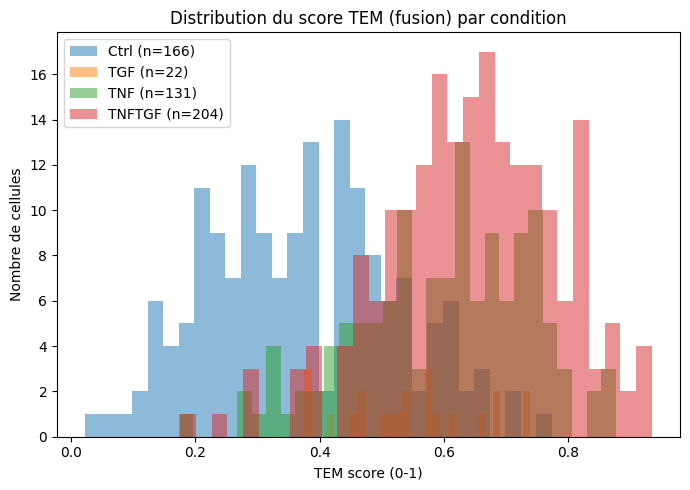

✅ Figure sauvegardée : /content/outputs_tem/tem_hist_by_condition.png

Ce que tu dois vérifier :
- CTRL doit avoir la distribution la plus à gauche
- TNFTGF la plus à droite
- TGF/TNF doivent être entre les deux (si transition progressive)


In [ ]:
print("=== CELLULE 11 : Figure principale (Histogramme) ===")
print("Pourquoi ? Visualiser simplement la distribution du score TEM par condition.")
print("Bio : CTRL doit être plutôt à gauche (score bas), TNFTGF plutôt à droite (score haut).")
print("------------------------------------------------------------\n")

import matplotlib.pyplot as plt

# Histogrammes du score TEM fusionné par condition
plt.figure(figsize=(7,5))
for c in conds:
    vals = df[df["condition"] == c]["tem_fused"].values
    plt.hist(vals, bins=30, alpha=0.5, label=f"{c} (n={len(vals)})")

plt.title("Distribution du score TEM (fusion) par condition")
plt.xlabel("TEM score (0-1)")
plt.ylabel("Nombre de cellules")
plt.legend()
plt.tight_layout()

# Sauvegarde
plt.savefig(f"{OUT_DIR}/tem_hist_by_condition.png", dpi=200)
plt.show()

print("✅ Figure sauvegardée :", f"{OUT_DIR}/tem_hist_by_condition.png")
print("\nCe que tu dois vérifier :")
print("- CTRL doit avoir la distribution la plus à gauche")
print("- TNFTGF la plus à droite")
print("- TGF/TNF doivent être entre les deux (si transition progressive)")


In [ ]:
print("=== CELLULE : Tableau récapitulatif des métriques (avec test de Student) ===")
print("Pourquoi ? Regrouper toutes les métriques au même endroit + ajouter une preuve statistique (t-test).")
print("Bio : tester si CTRL et TNFTGF ont des scores TEM significativement différents.")
print("------------------------------------------------------------\n")

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind

# --- Sanity checks : df doit exister ---
required_cols = {"condition", "tem_fused", "tem_actin", "tem_nucleus"}
missing = required_cols - set(df.columns)
if missing:
    raise RuntimeError(f"❌ Il manque des colonnes dans df : {missing}. Exécute d'abord les cellules qui créent df.")

CTRL_NAME = "Ctrl"
MES_NAME  = "TNFTGF"

if CTRL_NAME not in df["condition"].unique() or MES_NAME not in df["condition"].unique():
    raise RuntimeError(f"❌ Conditions {CTRL_NAME} et/ou {MES_NAME} absentes. Vérifie les noms de dossiers/conditions.")

print("✅ df OK. Nb cellules total =", len(df))
print("Conditions présentes :", sorted(df["condition"].unique()))
print()

# --- (1) Statistiques par condition ---
stats = (
    df.groupby("condition")["tem_fused"]
      .agg(
          n="count",
          mean="mean",
          std="std",
          median="median",
          q25=lambda x: x.quantile(0.25),
          q75=lambda x: x.quantile(0.75),
      )
      .reset_index()
)

# Ordonner selon la moyenne (du plus épithélial vers plus mésenchymateux)
stats = stats.sort_values("mean").reset_index(drop=True)

print("=== (1) Stats par condition (TEM fusion) ===")
display(stats)

# --- (2) Métriques globales ---
# AUC CTRL vs TNFTGF (séparation des extrêmes)
mask = df["condition"].isin([CTRL_NAME, MES_NAME])
y_auc = (df["condition"] == MES_NAME).astype(int)
auc = roc_auc_score(y_auc[mask], df.loc[mask, "tem_fused"])

# Corrélation actine vs noyau (cohérence marqueurs)
corr = float(np.corrcoef(df["tem_actin"].values, df["tem_nucleus"].values)[0, 1])

# Overlap CTRL vs TNFTGF (recouvrement distributions)
def overlap_between(a, b, bins=200):
    hist_a, edges = np.histogram(a, bins=bins, range=(0, 1), density=True)
    hist_b, _     = np.histogram(b, bins=bins, range=(0, 1), density=True)
    dx = edges[1] - edges[0]
    return float(np.sum(np.minimum(hist_a, hist_b)) * dx)

ctrl_vals = df[df["condition"] == CTRL_NAME]["tem_fused"].values
mes_vals  = df[df["condition"] == MES_NAME]["tem_fused"].values
ov = overlap_between(ctrl_vals, mes_vals)

# Cohen's d (taille d'effet)
def cohens_d(x, y, eps=1e-12):
    x = np.asarray(x); y = np.asarray(y)
    nx, ny = len(x), len(y)
    vx, vy = x.var(ddof=1), y.var(ddof=1)
    pooled = np.sqrt(((nx-1)*vx + (ny-1)*vy) / (nx+ny-2 + eps))
    return float((y.mean() - x.mean()) / (pooled + eps))

d = cohens_d(ctrl_vals, mes_vals)

mean_ctrl = float(ctrl_vals.mean())
mean_mes  = float(mes_vals.mean())
delta_mean = mean_mes - mean_ctrl

# --- (3) Test de Student (Welch) CTRL vs TNFTGF ---
# Welch t-test = version plus robuste si variances différentes + tailles différentes
t_stat, p_val = ttest_ind(ctrl_vals, mes_vals, equal_var=False)

print("=== (2) Test de Student (Welch) CTRL vs TNFTGF ===")
print("Hypothèse nulle H0 : les moyennes des scores TEM sont égales.")
print("t-stat =", round(float(t_stat), 4))
print("p-value =", float(p_val))
print("Interprétation rapide : si p-value < 0.05 => différence significative des moyennes.")
print()

# --- (4) Tableau récapitulatif final ---
metrics_table = pd.DataFrame([
    {
        "metric": "AUC (CTRL vs TNFTGF)",
        "value": float(auc),
        "good_if": "proche de 1 (0.5 = hasard)",
        "bio_interpretation": "Séparation épithélial vs mésenchymateux (sur les extrêmes)"
    },
    {
        "metric": "Cohen's d (CTRL → TNFTGF)",
        "value": float(d),
        "good_if": "≥0.8 = grand effet",
        "bio_interpretation": "Taille d'effet morphologique entre états extrêmes"
    },
    {
        "metric": "Différence de moyenne (TNFTGF - CTRL)",
        "value": float(delta_mean),
        "good_if": "positive et assez grande",
        "bio_interpretation": "Amplitude moyenne du shift TEM entre extrêmes"
    },
    {
        "metric": "Student t-test Welch: t-stat (CTRL vs TNFTGF)",
        "value": float(t_stat),
        "good_if": "valeur absolue grande",
        "bio_interpretation": "Statistique du test (plus c'est grand, plus les moyennes diffèrent)"
    },
    {
        "metric": "Student t-test Welch: p-value (CTRL vs TNFTGF)",
        "value": float(p_val),
        "good_if": "< 0.05 (souvent) / < 0.01 (très solide)",
        "bio_interpretation": "Probabilité d'observer une telle différence si H0 était vraie"
    },
    {
        "metric": "Overlap distributions (CTRL vs TNFTGF)",
        "value": float(ov),
        "good_if": "proche de 0 (1 = identiques)",
        "bio_interpretation": "Recouvrement des distributions : plus petit = mieux séparé"
    },
    {
        "metric": "Corrélation (TEM actine vs TEM noyau)",
        "value": float(corr),
        "good_if": "positive",
        "bio_interpretation": "Cohérence entre marqueurs (complémentaires si corr modérée)"
    },
    {
        "metric": "Mean CTRL (TEM fused)",
        "value": float(mean_ctrl),
        "good_if": "plutôt bas",
        "bio_interpretation": "Référence épithéliale"
    },
    {
        "metric": "Mean TNFTGF (TEM fused)",
        "value": float(mean_mes),
        "good_if": "plutôt haut",
        "bio_interpretation": "Référence mésenchymateuse"
    },
])

print("=== (3) Tableau récapitulatif des métriques globales ===")
display(metrics_table)

# --- (5) Export (optionnel) ---
import os
OUT_DIR = "/content/outputs_tem"
os.makedirs(OUT_DIR, exist_ok=True)

stats_path = f"{OUT_DIR}/table_stats_by_condition.csv"
metrics_path = f"{OUT_DIR}/table_metrics_summary.csv"

stats.to_csv(stats_path, index=False)
metrics_table.to_csv(metrics_path, index=False)

print("\n✅ Tables sauvegardées :")
print(" -", stats_path)
print(" -", metrics_path)

print("\nGuide de lecture ultra simple :")
print("- p-value petite => CTRL et TNFTGF ont des scores TEM vraiment différents (significatif).")
print("- AUC élevée + overlap faible => bonne séparation des extrêmes.")
print("- Cohen's d grand => gros effet morphologique.")


=== CELLULE : Tableau récapitulatif des métriques (avec test de Student) ===
Pourquoi ? Regrouper toutes les métriques au même endroit + ajouter une preuve statistique (t-test).
Bio : tester si CTRL et TNFTGF ont des scores TEM significativement différents.
------------------------------------------------------------

✅ df OK. Nb cellules total = 523
Conditions présentes : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']

=== (1) Stats par condition (TEM fusion) ===


,condition,n,mean,std,median,q25,q75
0,Ctrl,166,0.372082,0.151756,0.366558,0.261717,0.476267
1,TGF,22,0.544649,0.110825,0.538954,0.463876,0.605614
2,TNF,131,0.597557,0.141150,0.619788,0.506268,0.704714
3,TNFTGF,204,0.643449,0.140167,0.649704,0.562815,0.741807


=== (2) Test de Student (Welch) CTRL vs TNFTGF ===
Hypothèse nulle H0 : les moyennes des scores TEM sont égales.
t-stat = -17.7004
p-value = 3.6664429230089984e-50
Interprétation rapide : si p-value < 0.05 => différence significative des moyennes.

=== (3) Tableau récapitulatif des métriques globales ===


,metric,value,good_if,bio_interpretation
0,AUC (CTRL vs TNFTGF),9.017836e-01,proche de 1 (0.5 = hasard),Séparation épithélial vs mésenchymateux (sur l...
1,Cohen's d (CTRL → TNFTGF),1.865355e+00,≥0.8 = grand effet,Taille d'effet morphologique entre états extrêmes
2,Différence de moyenne (TNFTGF - CTRL),2.713665e-01,positive et assez grande,Amplitude moyenne du shift TEM entre extrêmes
3,Student t-test Welch: t-stat (CTRL vs TNFTGF),-1.770044e+01,valeur absolue grande,"Statistique du test (plus c'est grand, plus le..."
4,Student t-test Welch: p-value (CTRL vs TNFTGF),3.666443e-50,< 0.05 (souvent) / < 0.01 (très solide),Probabilité d'observer une telle différence si...
5,Overlap distributions (CTRL vs TNFTGF),2.860264e-01,proche de 0 (1 = identiques),Recouvrement des distributions : plus petit = ...
6,Corrélation (TEM actine vs TEM noyau),2.294727e-01,positive,Cohérence entre marqueurs (complémentaires si ...
7,Mean CTRL (TEM fused),3.720822e-01,plutôt bas,Référence épithéliale
8,Mean TNFTGF (TEM fused),6.434487e-01,plutôt haut,Référence mésenchymateuse



✅ Tables sauvegardées :
 - /content/outputs_tem/table_stats_by_condition.csv
 - /content/outputs_tem/table_metrics_summary.csv

Guide de lecture ultra simple :
- p-value petite => CTRL et TNFTGF ont des scores TEM vraiment différents (significatif).
- AUC élevée + overlap faible => bonne séparation des extrêmes.
- Cohen's d grand => gros effet morphologique.


In [ ]:
print("=== IMPORT DU DATASET FRESQUE (images colorées) ===")

import zipfile
import os

ZIP_PATH = "/content/Celltool fresque.zip"   # chemin exact du zip
EXTRACT_DIR = "/content/dataset_fresque"     # dossier de sortie

# Créer le dossier d'extraction
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extraction
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extraction terminée.")
print("Dossier extrait :", EXTRACT_DIR)

# Affichage simple de l'arborescence
print("\nStructure du dossier :")
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # évite d'afficher trop de fichiers
        for f in files[:5]:
            print(f"{indent}  {f}")


=== IMPORT DU DATASET FRESQUE (images colorées) ===
Extraction terminée.
Dossier extrait : /content/dataset_fresque

Structure du dossier :
dataset_fresque/
  Celltool fresque/
    TGF/
    TNFTGF/
    TNF/
    Ctrl/


In [ ]:
FRESQUE_DIR = "/content/dataset_fresque"


=== CELLULE : Démo aléatoire + image FRESQUE (colorée) + histogramme ===
But : choisir une cellule au hasard, afficher l'image colorée complète, et la positionner sur l'histogramme TEM.
Bio : vérifier visuellement si elle ressemble plutôt à CTRL (score bas) ou TNFTGF (score haut).
------------------------------------------------------------

✅ Fresque root : /content/dataset_fresque/Celltool fresque
Conditions dispo dans fresque : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']

Cellule choisie au hasard ✅
 - sample_id : TNFTGF/TNFTGF98.png
 - condition : TNFTGF
 - tem_fused : 0.830
👉 Interprétation : plutôt mésenchymateuse (proche 1 / TNFTGF-like)

Chemin image colorée : /content/dataset_fresque/Celltool fresque/TNFTGF/TNFTGF98.png


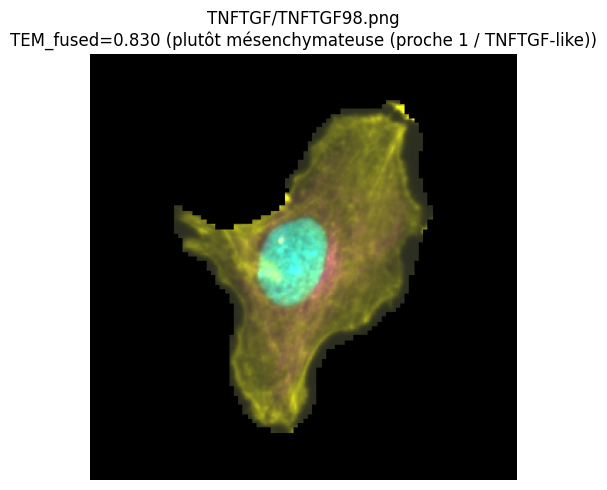

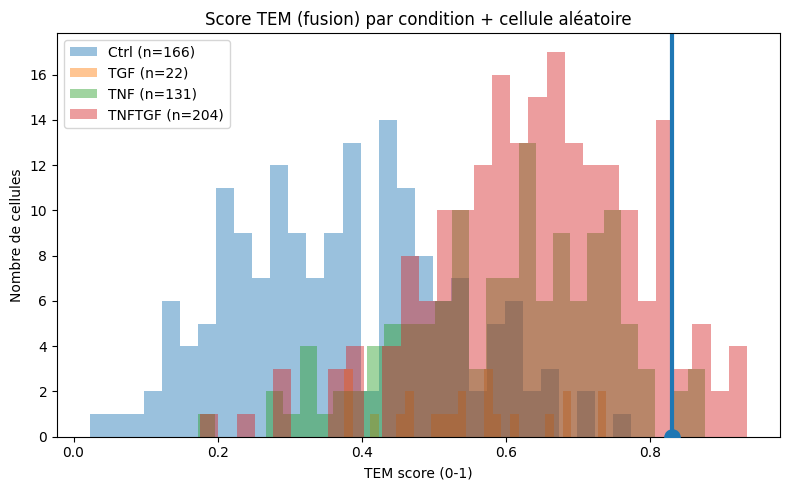


✅ Figure sauvegardée : /content/outputs_tem/random_cell_fresque_on_hist.png
Lecture bio : la ligne verticale montre où se situe cette cellule par rapport aux distributions.


In [ ]:
print("=== CELLULE : Démo aléatoire + image FRESQUE (colorée) + histogramme ===")
print("But : choisir une cellule au hasard, afficher l'image colorée complète, et la positionner sur l'histogramme TEM.")
print("Bio : vérifier visuellement si elle ressemble plutôt à CTRL (score bas) ou TNFTGF (score haut).")
print("------------------------------------------------------------\n")

import os, re
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

# --- Checks ---
needed = {"sample_id", "condition", "tem_fused"}
missing = needed - set(df.columns)
if missing:
    raise RuntimeError(f"❌ df n'a pas les colonnes requises : {missing}")

FRESQUE_ROOT = Path("/content/dataset_fresque/Celltool fresque")
if not FRESQUE_ROOT.exists():
    raise RuntimeError(f"❌ Dossier fresque introuvable : {FRESQUE_ROOT}")

print("✅ Fresque root :", FRESQUE_ROOT)
print("Conditions dispo dans fresque :", sorted([d.name for d in FRESQUE_ROOT.iterdir() if d.is_dir()]))
print()

# --- 1) Choisir une cellule au hasard ---
row = df.sample(1).iloc[0]
sample_id = row["sample_id"]          # ex: "Ctrl/Ctrl0.png"
cond      = row["condition"]          # ex: "Ctrl"
fname     = sample_id.split("/", 1)[1]  # ex: "Ctrl0.png"
temF      = float(row["tem_fused"])

print("Cellule choisie au hasard ✅")
print(" - sample_id :", sample_id)
print(" - condition :", cond)
print(f" - tem_fused : {temF:.3f}")

if temF < 0.33:
    interp = "plutôt épithéliale (proche 0 / CTRL-like)"
elif temF > 0.66:
    interp = "plutôt mésenchymateuse (proche 1 / TNFTGF-like)"
else:
    interp = "intermédiaire (transition / hybride possible)"
print("👉 Interprétation :", interp)
print()

# --- 2) Retrouver l'image colorée ---
img_path = FRESQUE_ROOT / cond / fname

# Si le nom exact n'existe pas, on tente une recherche
if not img_path.exists():
    print("⚠️ Image non trouvée au chemin attendu :", img_path)
    base = Path(fname).stem
    candidates = list((FRESQUE_ROOT / cond).glob(base + ".*"))
    if len(candidates) > 0:
        img_path = candidates[0]
        print("✅ Trouvée via recherche :", img_path)
    else:
        pat = re.compile(re.escape(base), re.IGNORECASE)
        all_files = list((FRESQUE_ROOT / cond).glob("*"))
        approx = [p for p in all_files if pat.search(p.stem)]
        if len(approx) > 0:
            img_path = approx[0]
            print("✅ Trouvée via recherche approx :", img_path)
        else:
            raise RuntimeError(f"❌ Impossible de retrouver l'image fresque pour {cond}/{fname}.")

print("Chemin image colorée :", img_path)

# --- 3) Afficher l'image colorée ---
img = Image.open(img_path)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(f"{sample_id}\nTEM_fused={temF:.3f} ({interp})")
plt.axis("off")
plt.tight_layout()
plt.show()

# --- 4) Histogramme + position de la cellule ---
conds = sorted(df["condition"].unique())

plt.figure(figsize=(8,5))
for c in conds:
    vals = df[df["condition"] == c]["tem_fused"].values
    plt.hist(vals, bins=30, alpha=0.45, label=f"{c} (n={len(vals)})")

# Marqueur visible
plt.axvline(temF, linewidth=3)
plt.scatter([temF], [0], s=120, marker="o", zorder=5)

plt.title("Score TEM (fusion) par condition + cellule aléatoire")
plt.xlabel("TEM score (0-1)")
plt.ylabel("Nombre de cellules")
plt.legend()
plt.tight_layout()

out_path = "/content/outputs_tem/random_cell_fresque_on_hist.png"
os.makedirs("/content/outputs_tem", exist_ok=True)
plt.savefig(out_path, dpi=200)
plt.show()

print("\n✅ Figure sauvegardée :", out_path)
print("Lecture bio : la ligne verticale montre où se situe cette cellule par rapport aux distributions.")


=== CELLULE : 3 exemples ALÉATOIRES (zone proche 0 / zone ~0.45 / zone proche 1) + images FRESQUE + histogramme ===
But : illustrer visuellement le continuum TEM avec 3 cellules représentatives (tirées au hasard dans des zones).
Bio : épithéliale (bas), intermédiaire (transition), mésenchymateuse (haut).
------------------------------------------------------------

✅ Fresque root : /content/dataset_fresque/Celltool fresque
Conditions dispo dans fresque : ['Ctrl', 'TGF', 'TNF', 'TNFTGF']

Cellules sélectionnées aléatoirement (1 par zone) :
- Zone proche de 0 (épithéliale) | zone=0.00–0.15 | score=0.127 | Ctrl/Ctrl93.png
- Zone ~0.45 (intermédiaire) | zone=0.35–0.55 | score=0.383 | TNF/TNF49.png
- Zone proche de 1 (mésenchymateuse) | zone=0.85–1.00 | score=0.926 | TNFTGF/TNFTGF99.png



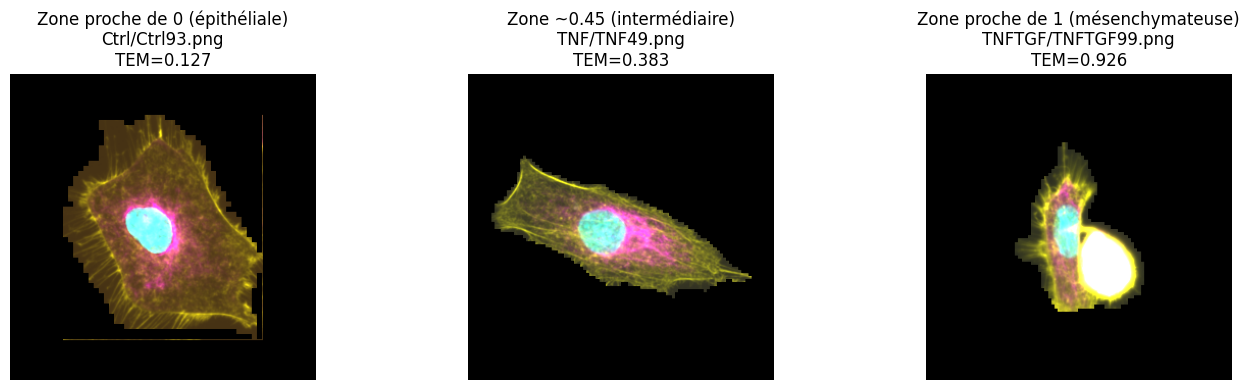

✅ Image 3-exemples sauvegardée : /content/outputs_tem/three_examples_fresque_random.png



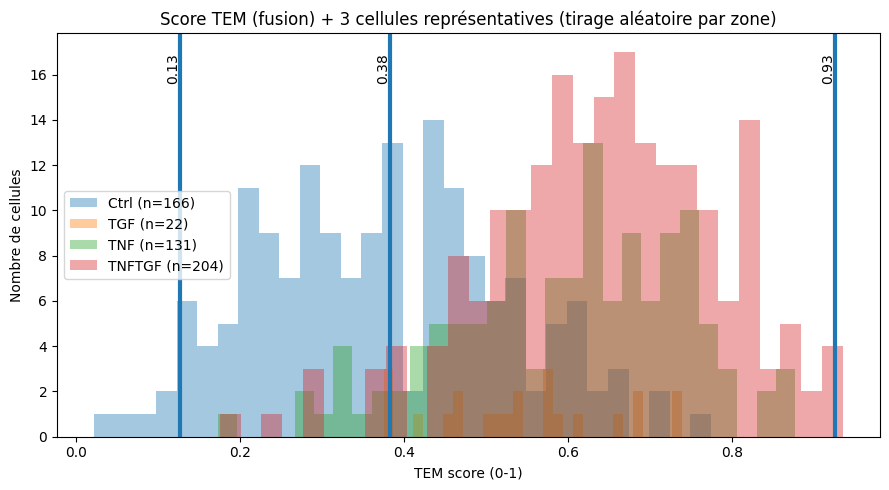

✅ Histogramme sauvegardé : /content/outputs_tem/hist_with_three_examples_random.png

Lecture bio :
- Zone proche de 0 : cellule plutôt épithéliale (CTRL-like).
- Zone ~0.45 : cellule en transition / hybride possible.
- Zone proche de 1 : cellule plutôt mésenchymateuse (TNFTGF-like).


In [ ]:
print("=== CELLULE : 3 exemples ALÉATOIRES (zone proche 0 / zone ~0.45 / zone proche 1) + images FRESQUE + histogramme ===")
print("But : illustrer visuellement le continuum TEM avec 3 cellules représentatives (tirées au hasard dans des zones).")
print("Bio : épithéliale (bas), intermédiaire (transition), mésenchymateuse (haut).")
print("------------------------------------------------------------\n")

import os, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- Checks ---
needed = {"sample_id", "condition", "tem_fused"}
missing = needed - set(df.columns)
if missing:
    raise RuntimeError(f"❌ df n'a pas les colonnes requises : {missing}")

FRESQUE_ROOT = Path("/content/dataset_fresque/Celltool fresque")
if not FRESQUE_ROOT.exists():
    raise RuntimeError(f"❌ Dossier fresque introuvable : {FRESQUE_ROOT}")

print("✅ Fresque root :", FRESQUE_ROOT)
print("Conditions dispo dans fresque :", sorted([d.name for d in FRESQUE_ROOT.iterdir() if d.is_dir()]))
print()

# --- Helper: retrouver une image colorée à partir (cond, filename) ---
def find_fresque_image(cond, fname):
    img_path = FRESQUE_ROOT / cond / fname
    if img_path.exists():
        return img_path

    # sinon : chercher même base sans extension
    base = Path(fname).stem
    candidates = list((FRESQUE_ROOT / cond).glob(base + ".*"))
    if candidates:
        return candidates[0]

    # dernier recours : recherche approx
    pat = re.compile(re.escape(base), re.IGNORECASE)
    approx = [p for p in (FRESQUE_ROOT / cond).glob("*") if pat.search(p.stem)]
    if approx:
        return approx[0]

    return None

# --- 1) Choisir 3 cellules AU HASARD dans des zones de score ---
zones = [
    ("Zone proche de 0 (épithéliale)", 0.00, 0.15),
    ("Zone ~0.45 (intermédiaire)",     0.35, 0.55),
    ("Zone proche de 1 (mésenchymateuse)", 0.85, 1.00),
]

picked = []
for label, lo, hi in zones:
    subset = df[(df["tem_fused"] >= lo) & (df["tem_fused"] <= hi)]
    if len(subset) == 0:
        raise RuntimeError(f"❌ Aucune cellule dans la zone '{label}' ({lo:.2f}–{hi:.2f}). Ajuste les bornes.")
    row = subset.sample(1).iloc[0]  # tirage aléatoire
    picked.append((label, (lo, hi), row))

print("Cellules sélectionnées aléatoirement (1 par zone) :")
for label, (lo, hi), row in picked:
    print(f"- {label} | zone={lo:.2f}–{hi:.2f} | score={float(row['tem_fused']):.3f} | {row['sample_id']}")
print()

# --- 2) Afficher les 3 images colorées ---
plt.figure(figsize=(14,4))
for i, (label, (lo, hi), row) in enumerate(picked, start=1):
    sample_id = row["sample_id"]           # ex: "Ctrl/Ctrl0.png"
    cond      = row["condition"]           # ex: "Ctrl"
    fname     = sample_id.split("/", 1)[1] # ex: "Ctrl0.png"
    score     = float(row["tem_fused"])

    img_path = find_fresque_image(cond, fname)
    if img_path is None:
        raise RuntimeError(f"❌ Image fresque introuvable pour {cond}/{fname}")

    img = Image.open(img_path)

    plt.subplot(1,3,i)
    plt.imshow(img)
    plt.title(f"{label}\n{sample_id}\nTEM={score:.3f}")
    plt.axis("off")

plt.tight_layout()
os.makedirs("/content/outputs_tem", exist_ok=True)
out_img = "/content/outputs_tem/three_examples_fresque_random.png"
plt.savefig(out_img, dpi=200)
plt.show()
print("✅ Image 3-exemples sauvegardée :", out_img)
print()

# --- 3) Histogramme + 3 marqueurs ---
plt.figure(figsize=(9,5))
conds = sorted(df["condition"].unique())
for c in conds:
    vals = df[df["condition"] == c]["tem_fused"].values
    plt.hist(vals, bins=30, alpha=0.40, label=f"{c} (n={len(vals)})")

# Traits verticaux + étiquettes
ymax = plt.ylim()[1]
for (label, (lo, hi), row) in picked:
    score = float(row["tem_fused"])
    plt.axvline(score, linewidth=3)
    plt.text(score, ymax*0.95, f"{score:.2f}", rotation=90, va="top", ha="right")

plt.title("Score TEM (fusion) + 3 cellules représentatives (tirage aléatoire par zone)")
plt.xlabel("TEM score (0-1)")
plt.ylabel("Nombre de cellules")
plt.legend()
plt.tight_layout()

out_hist = "/content/outputs_tem/hist_with_three_examples_random.png"
plt.savefig(out_hist, dpi=200)
plt.show()

print("✅ Histogramme sauvegardé :", out_hist)
print("\nLecture bio :")
print("- Zone proche de 0 : cellule plutôt épithéliale (CTRL-like).")
print("- Zone ~0.45 : cellule en transition / hybride possible.")
print("- Zone proche de 1 : cellule plutôt mésenchymateuse (TNFTGF-like).")
